In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
np.random.seed(1)

In [68]:
# Computing correlation matrix

participants = 200

df = pd.DataFrame({
    "Height": np.random.normal(loc= 170, scale=10, size=participants),
    "Weight": np.random.normal(loc=70, scale=8, size=participants),
    "Age": np.random.normal(loc=30, scale=5, size=participants),
    "Income": np.random.normal(loc=50000, scale=10000, size=participants)
})

print(df.head())

# Computing correlations:
corr_matrix = df.corr()

print("\nCorrolations:\n", corr_matrix)

       Height     Weight        Age        Income
0  186.243454  66.792974  23.467330  39270.357213
1  163.882436  76.592045  30.381902  54951.586112
2  164.718282  65.501557  31.836159  40479.378993
3  159.270314  85.639025  36.164496  44818.544476
4  178.654076  59.344387  27.885715  35385.963953

Corrolations:
           Height    Weight       Age    Income
Height  1.000000 -0.048504 -0.016243 -0.083098
Weight -0.048504  1.000000  0.070590  0.100457
Age    -0.016243  0.070590  1.000000  0.095489
Income -0.083098  0.100457  0.095489  1.000000


#### Heatmap

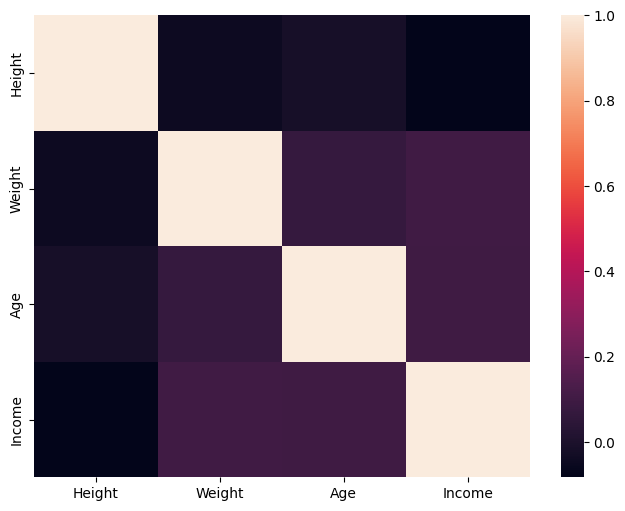

In [69]:
# Creating a heatmap.

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix)

plt.show()

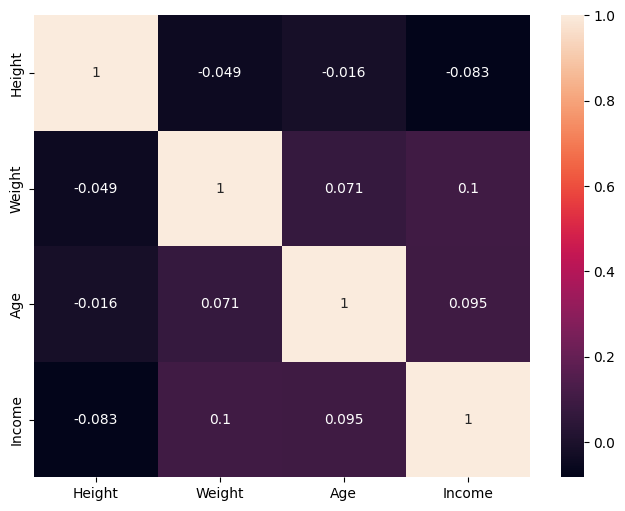

In [70]:
# Creating a heatmap with explanations.

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True
)

plt.show()

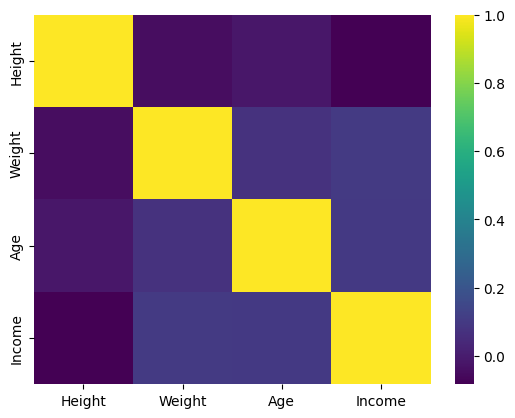

In [71]:
# Using differant colormaps.

sns.heatmap(corr_matrix,
            cmap="viridis")

plt.show()

Note: there is other colormaps like plasma, inferno, magma, cividis, coolwarm, RdBu, and YlGnBu.

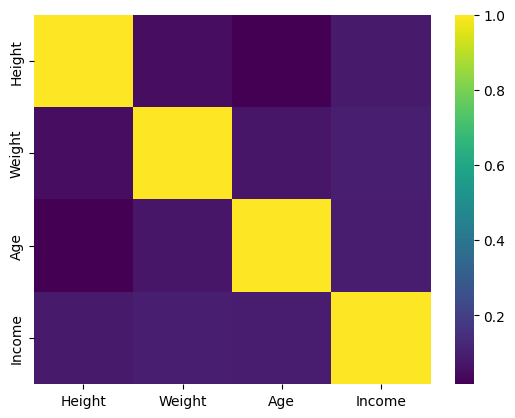

In [72]:
# Note: by using absolute correlations means values range whe can get more appropriate sequential colormap.

sns.heatmap(
    corr_matrix.abs(),
    cmap="viridis"
)

plt.show()

#### Diverging Colormaps

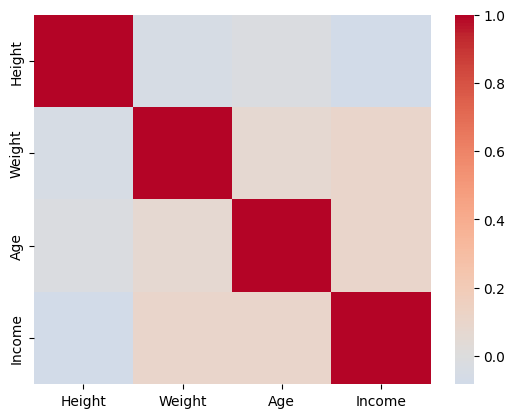

In [73]:
# We can diverging clormaps by setting a center point.

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.show()

Note: without setting a center point and diverging a colormap, color scaling can become misleading.

#### Masking Duplicate Information

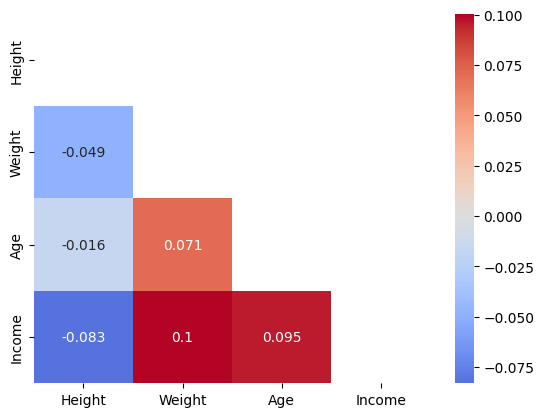

In [74]:
# Creating a mask for a heatmap plot.

mask = np.triu(
    np.ones_like(corr_matrix)
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

Note: sometimes we should rescaling for avoiding misleading color scaling

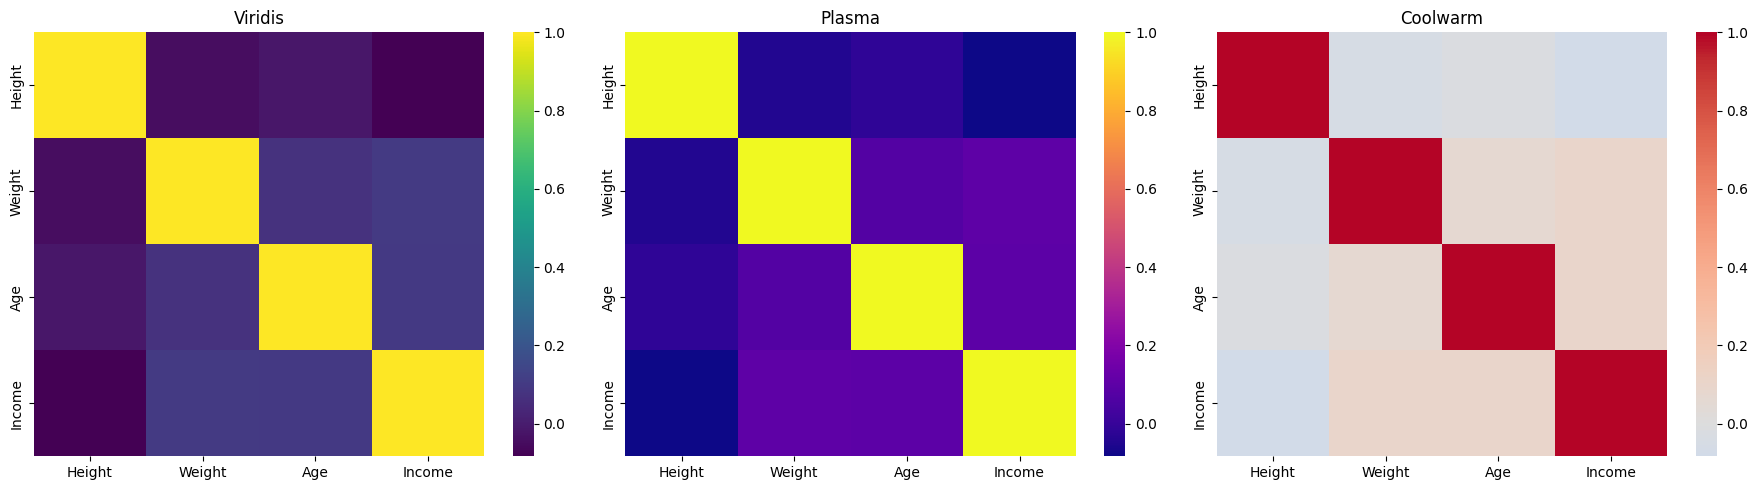

In [75]:
# Comparing multiple colormaps.

fig, axes = plt.subplots(
    1, 3,
    figsize=(18,5)
)

sns.heatmap(
    corr_matrix,
    cmap="viridis",
    ax=axes[0]
)
axes[0].set_title("Viridis")

sns.heatmap(
    corr_matrix,
    cmap="plasma",
    ax=axes[1]
)
axes[1].set_title("Plasma")

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    ax=axes[2]
)
axes[2].set_title("Coolwarm")

plt.tight_layout()
plt.show()

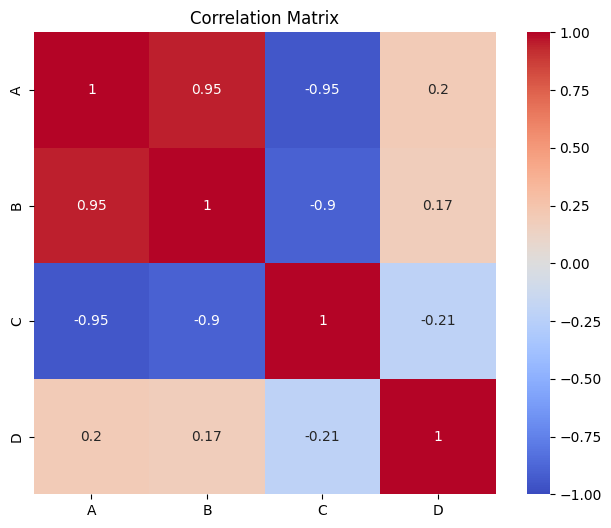

In [76]:
# Another example of creating a heatmap with rescaling.

x = np.random.normal(size=participants)

df = pd.DataFrame({
    "A": x,
    "B": x + np.random.normal(scale=0.3, size=participants),
    "C": -x + np.random.normal(scale=0.3, size=participants),
    "D": np.random.normal(size=participants)
})

corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Matrix")

plt.show()

#### Subplots and Figure Layout 

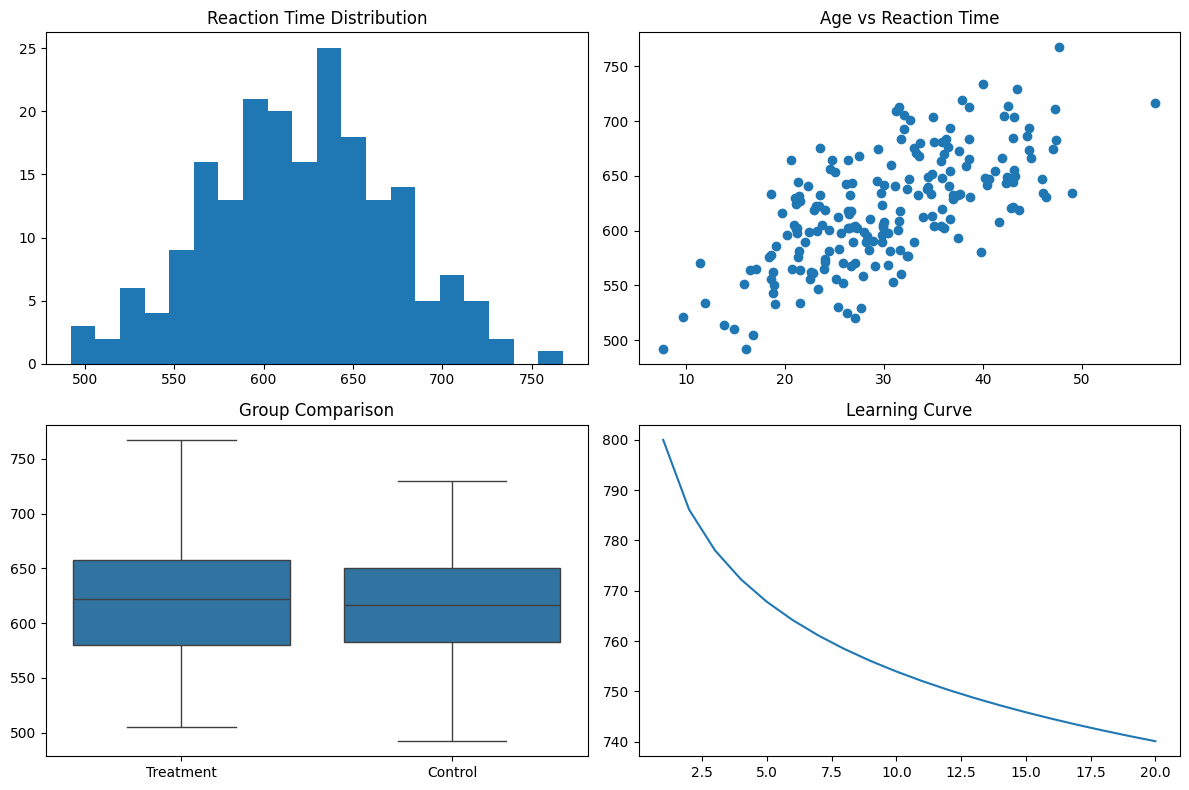

In [77]:
# Creating a subplot.

age = np.random.normal(loc=30, scale=8, size=participants)

reaction_time = (
    500
    + age*4
    + np.random.normal(loc=0, scale=40, size=participants)
)

group = np.random.choice(
    ["Control","Treatment"],
    participants
)

trials = np.arange(1,21)

learning_curve = (
    800
    - 20*np.log(trials)
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

# Histogram
axes[0,0].hist(
    reaction_time,
    bins=20
)
axes[0,0].set_title(
    "Reaction Time Distribution"
)

# Scatter
axes[0,1].scatter(
    age,
    reaction_time
)
axes[0,1].set_title(
    "Age vs Reaction Time"
)

# Boxplot
sns.boxplot(
    x=group,
    y=reaction_time,
    ax=axes[1,0]
)
axes[1,0].set_title(
    "Group Comparison"
)

# Line Plot
axes[1,1].plot(
    trials,
    learning_curve
)
axes[1,1].set_title(
    "Learning Curve"
)

plt.tight_layout() # Automatically fixes spacing.

plt.show()

#### Pairplot

In [78]:
# Creating a new dataset same size.

new_df = pd.DataFrame({
    "Age": np.random.normal(loc=30, scale=8, size=participants),
    "IQ": np.random.normal(loc=100, scale=15, size=participants),
    "Accuracy": np.random.normal(loc=85, scale=5, size=participants),
    "ReactionTime": np.random.normal(loc=600, scale=80, size=participants),
    "Group": np.random.choice(
        ["Control", "Treatment"],
        size=participants
    )
})

df.head()

,A,B,C,D
0,0.814343,0.768372,-0.976053,0.189199
1,0.780470,0.050717,-0.587240,1.223936
2,-1.464054,-1.311658,1.519144,-0.300931
3,-0.154491,-0.251701,0.128563,0.251310
4,-0.092432,-0.545755,0.028236,0.928290


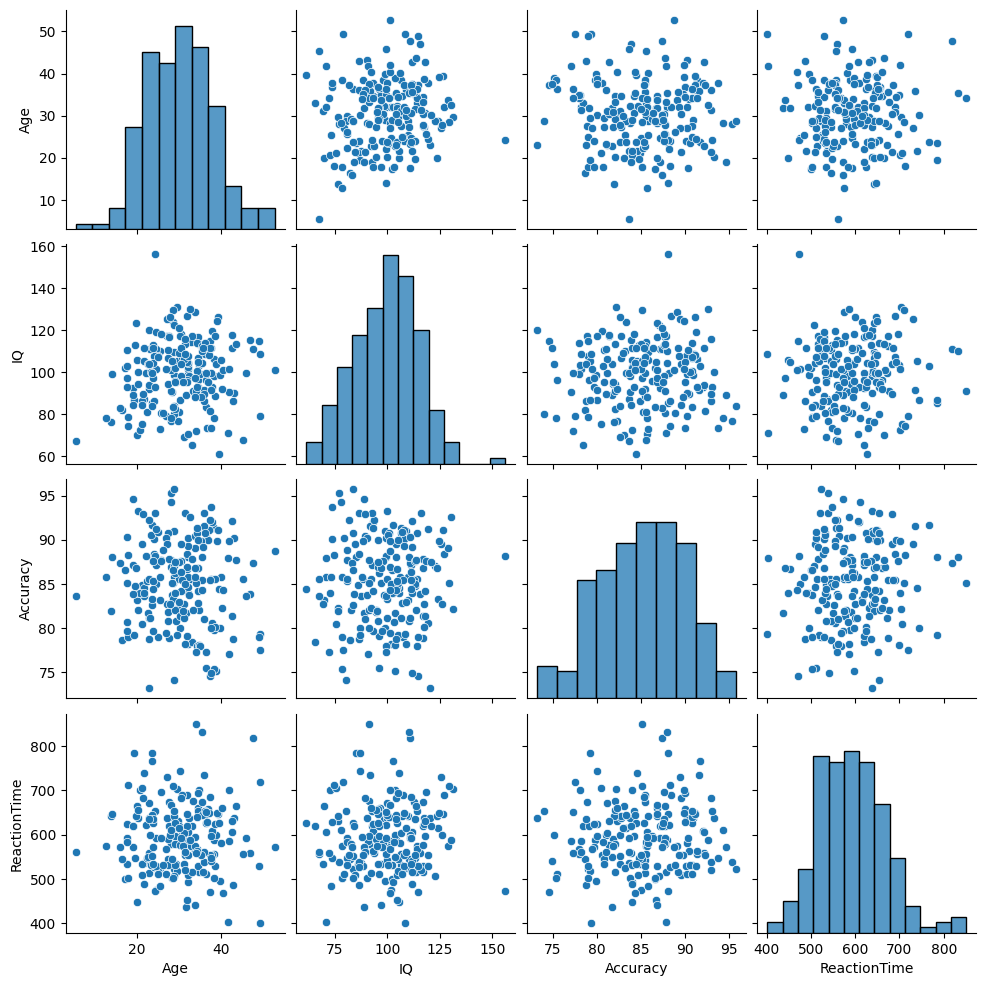

In [83]:
# Creating a pairplot.

sns.pairplot(new_df)

plt.show()

Note: a pairplot only suggests a hypothesis. It does not establish causality.

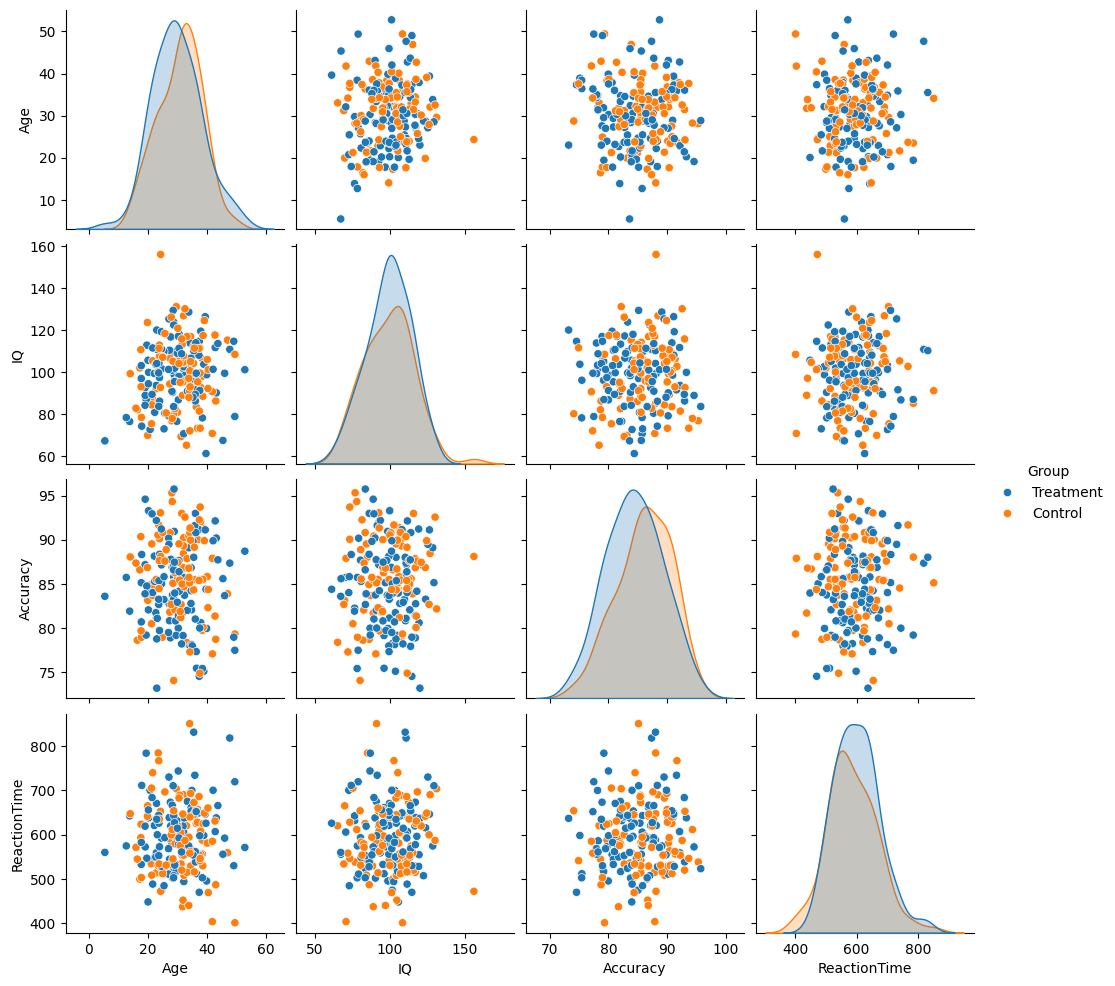

In [84]:
# Getting more information from a pairplot by showing coler by group.

sns.pairplot(
    new_df,
    hue="Group"
)

plt.show()

#### Jointplot

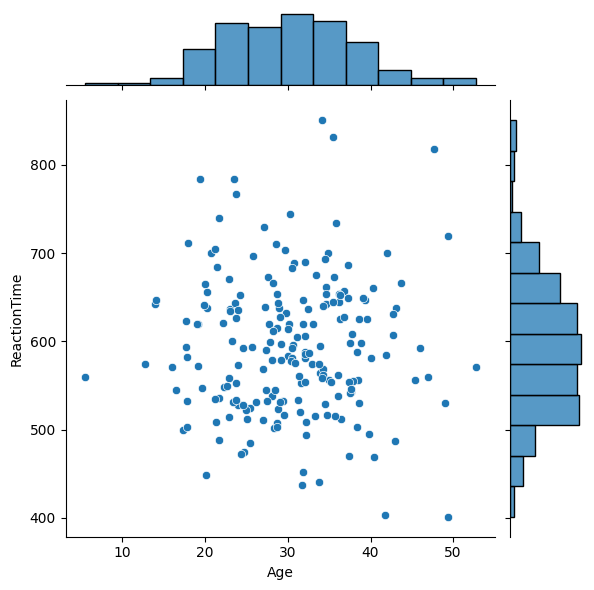

In [85]:
# Creating a jointplot.

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime"
)

plt.show()

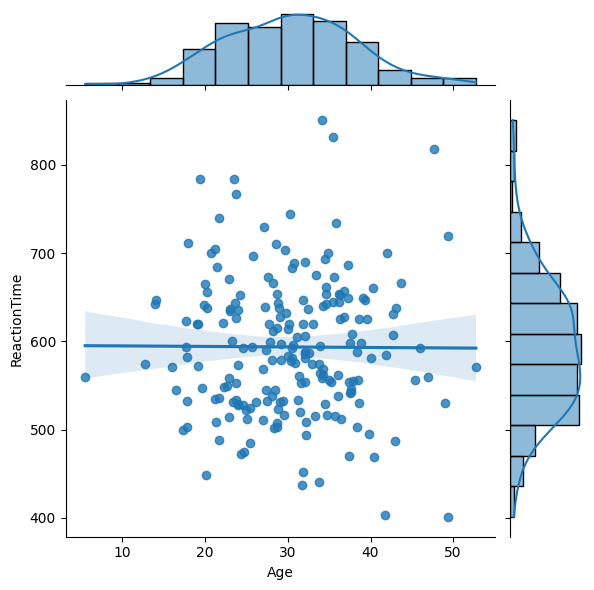

In [86]:
# Another example of jointplot with scatter, regression line, and marginal distributions.

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime",
    kind="reg"
)

plt.show()

#### Different Jointplot Types

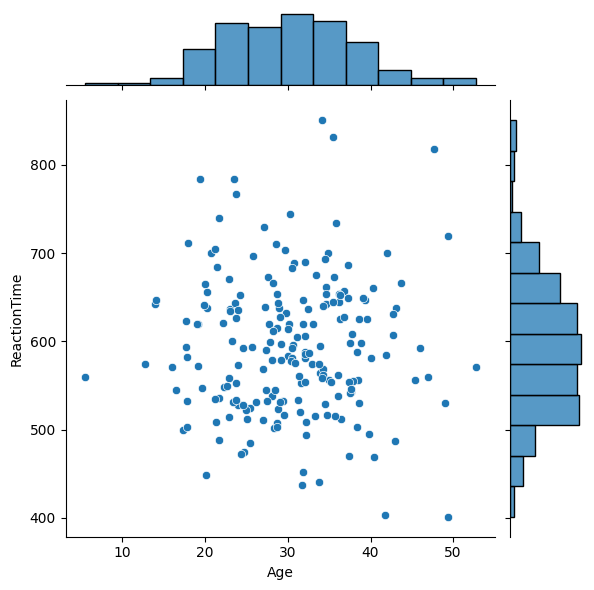

In [87]:
# Scatter

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime",
    kind="scatter"
)

plt.show()

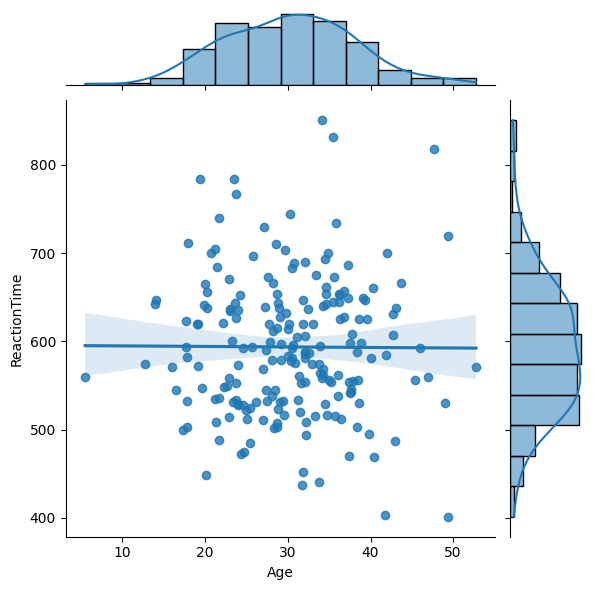

In [88]:
# Regression

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime",
    kind="reg"
)

plt.show()

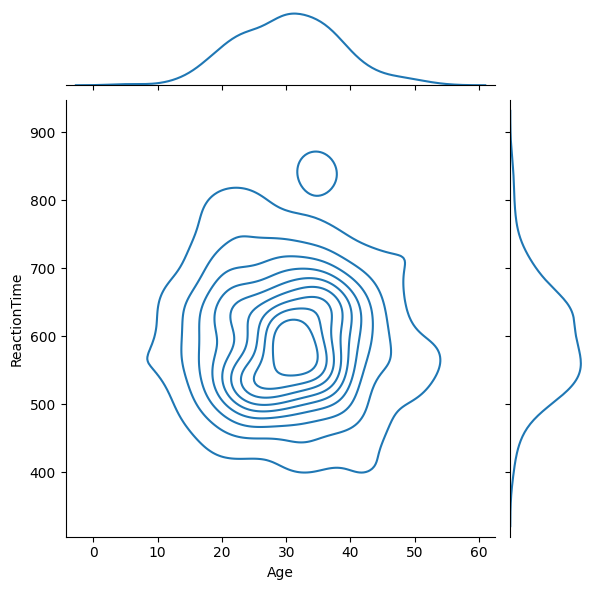

In [89]:
# KDE

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime",
    kind="kde"
)

plt.show()

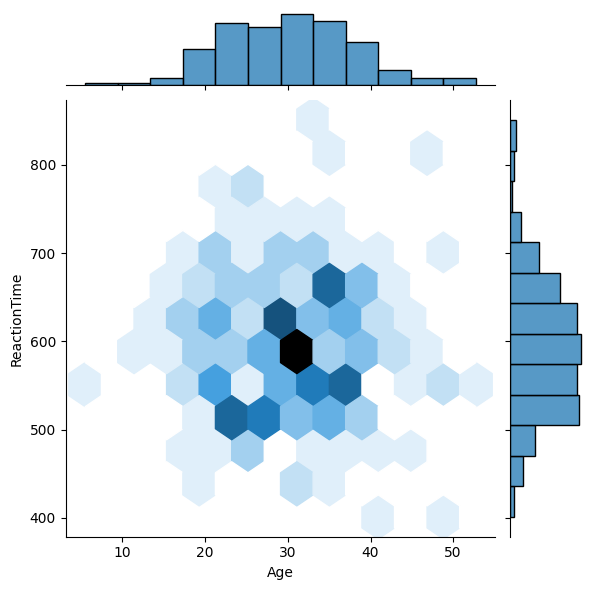

In [90]:
# Hexbin

sns.jointplot(
    data=new_df,
    x="Age",
    y="ReactionTime",
    kind="hex"
)

plt.show()

#### Catplot

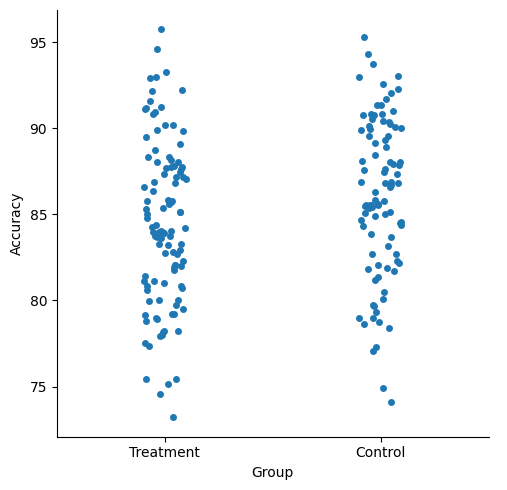

In [93]:
# Creatin catplot.

sns.catplot(
    data=new_df,
    x="Group",
    y="Accuracy"
)

plt.show()

#### FacetGrid

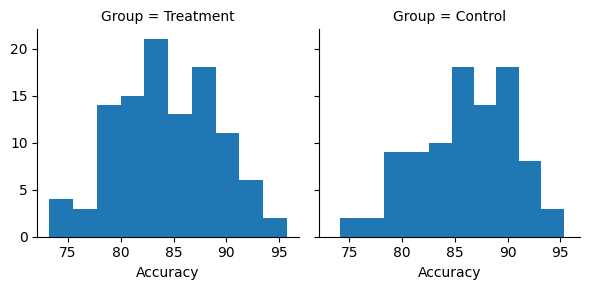

In [92]:
# Creatin facetgrid

g = sns.FacetGrid(
    new_df,
    col="Group"
)

g.map(
    plt.hist,
    "Accuracy"
)

plt.show()

Note: Instead of putting all groups in one figure (control and treatment) facetgrid separates them.

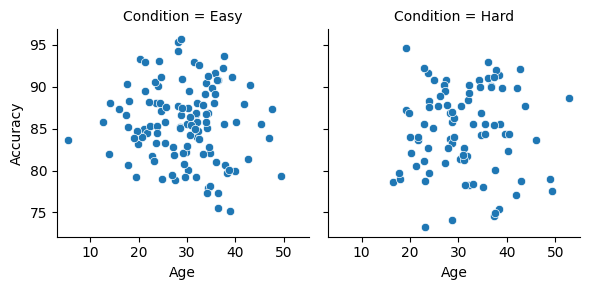

In [98]:
# Adding condition to new_df

new_df["Condition"] = np.random.choice(
    ["Easy", "Hard"],
    size=participants
)

# Creatin multiple facets

g = sns.FacetGrid(
    new_df,
    col="Condition"
)

g.map(
    sns.scatterplot,
    "Age",
    "Accuracy"
)

plt.show()